# Notebook 4c — RF con CV por animal: Lesiones TB — **SOLO granja VC30D**
### Tuberculosis bovina

Análisis restringido a los animales de la **explotación VC30D**.
Evalúa el Random Forest usando validación cruzada estratificada por animal
(RepeatedStratifiedKFold) sobre el subconjunto de VC30D.

> **Pregunta de investigación:** ¿pueden los biomarcadores individuales (vitamina D,
> calcio, serología parasitaria, edad, raza) predecir el estado de TB bovina *dentro
> de la explotación VC30D*? Al operar en una sola granja se elimina el efecto de
> confusión inter-granja y la señal refleja únicamente variabilidad individual.

**Comparar con:**
- *Notebook 2c*: mismo análisis sobre el cohorte completo sin Expl.
- *Notebook 3c*: cohorte completo con Expl como covariable.
- *Este notebook (4c)*: análisis intra-granja VC30D (máxima pureza individual).

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold)
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             brier_score_loss, matthews_corrcoef, recall_score,accuracy_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

GRANJA = "VC30D"

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

# Filtrar por explotación
d = tb.target_subset(df, "Lesiones_TB")
d = d[d[tb.GROUP_COL] == GRANJA].copy().reset_index(drop=True)
d = tb.drop_sparse_rows(d)

X_all = d[tb.MODEL_FEATURES].copy()
y     = d["Lesiones_TB"].astype(int).values

print(f"Explotación: {GRANJA}")
print(f"Dataset: n={len(y)}, prevalencia={y.mean():.3f}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print(f"Línea base PR-AUC (prevalencia) = {y.mean():.3f}")
print(f"\nNota: análisis restringido a VC30D. El confusor inter-granja está eliminado.")
print(f"La señal detectada refleja variabilidad individual dentro de esta explotación.")

Explotación: VC30D
Dataset: n=55, prevalencia=0.582
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Línea base PR-AUC (prevalencia) = 0.582

Nota: análisis restringido a VC30D. El confusor inter-granja está eliminado.
La señal detectada refleja variabilidad individual dentro de esta explotación.


## 2. Random Forest y estrategia de validación cruzada

**CV por animal en VC30D (RepeatedStratifiedKFold, 5×10):**
- Estratificado por `y` (balance de clases).
- Con n reducido (solo VC30D), la varianza del CV es mayor — interpretar con cautela.
- No hay información de granja en el modelo (constante = VC30D para todos).

In [10]:
def make_rf(n_estimators=100, min_samples_leaf=3):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        class_weight="balanced",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_4c(feature_list, n_estimators=100):
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_metrics_4c(feature_list, X, y, cv=None, detailed=False, n_estimators=100):
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_4c(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2:
            continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        p    = pf.predict_proba(Xs.iloc[te])[:, 1]
        pred = (p >= 0.5).astype(int)
        rows.append(dict(
            prauc = average_precision_score(y[te], p),
            roc   = roc_auc_score(y[te], p),
            brier = brier_score_loss(y[te], p),
            mcc   = matthews_corrcoef(y[te], pred),
            sens  = recall_score(y[te], pred, pos_label=1, zero_division=0),
            spec  = recall_score(y[te], pred, pos_label=0, zero_division=0),
            acc   = accuracy_score(y[te],pred)
        ))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.prauc.mean(), df_r.prauc.std()

print(f"Evaluación baseline RF ({GRANJA}):")
base_m, base_s = cv_metrics_4c(tb.MODEL_FEATURES, X_all, y)
print(f"  PR-AUC = {base_m:.3f} ± {base_s:.3f}")
print(f"  Línea base (prevalencia) = {y.mean():.3f}")

Evaluación baseline RF (VC30D):
  PR-AUC = 0.686 ± 0.107
  Línea base (prevalencia) = 0.582


## 3. Pipeline de selección de características

Mismo algoritmo que Notebooks 2c/3c:
1. Importancia de permutación sobre modelo completo (en muestra) → ranking.
2. Eliminación hacia atrás, calculando PR-AUC CV por animal en cada paso.
3. Subconjunto más pequeño con PR-AUC ≥ máx − 1·DE.

**Nota:** con n reducido (solo VC30D), la varianza del CV es mayor y la selección de
features puede ser menos estable. Los resultados deben interpretarse con cautela.

Paso 1: Ajustando RF completo en VC30D para ranking de importancia...
OOB Score (en muestra): 0.618

Ranking importancia de permutación (VC30D):
                 pretty  imp_mean  imp_std
                 Calcio    0.1035   0.0356
     Anaplasma spp. (+)    0.0568   0.0198
             Vitamina D    0.0384   0.0139
log(1+Carga piroplasma)    0.0333   0.0109
            Edad (años)    0.0243   0.0088
                   Raza    0.0081   0.0043
     Theileria spp. (+)    0.0045   0.0033
         Piroplasma (+)    0.0000   0.0000


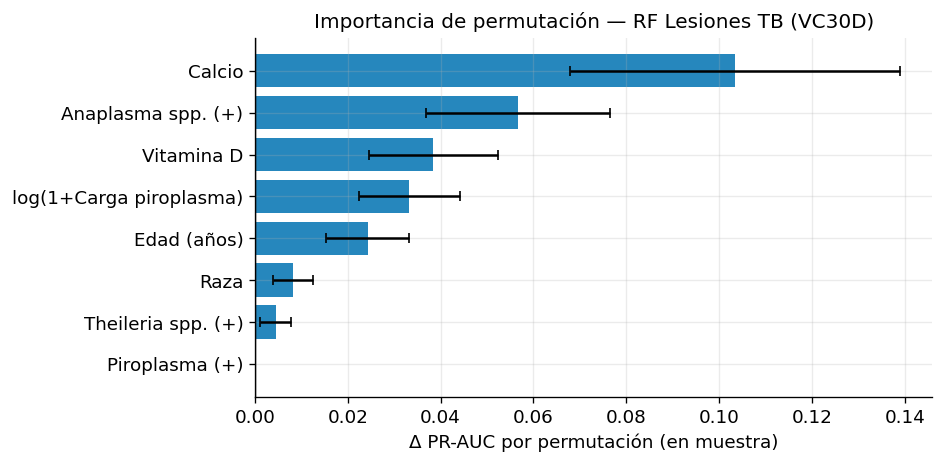

In [11]:
print(f"Paso 1: Ajustando RF completo en VC30D para ranking de importancia...")
full_pipe = make_pipe_4c(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="average_precision",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print(f"\nRanking importancia de permutación ({GRANJA}):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (en muestra)")
ax.set_title(f"Importancia de permutación — RF Lesiones TB ({GRANJA})")
plt.tight_layout(); plt.savefig("figures/fig_04c_perm_importance_full.png"); plt.show()

In [12]:
CV_SEL = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación: {elim_order}\n")
print(f"Paso 2: Eliminación hacia atrás ({GRANJA}, puede tardar 1-2 min)...\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_metrics_4c(current_features, X_all, y, cv=CV_SEL)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] PR-AUC={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1:
        break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_metrics_4c(test_feats, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] PR-AUC={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)

Orden de eliminación: ['PIROPLASMA', 'THEILERIA', 'RAZA2', 'EDAD', 'PIROPLASMA_Q_log', 'VITAMINA_D', 'ANAPLASMA', 'CALCIO']

Paso 2: Eliminación hacia atrás (VC30D, puede tardar 1-2 min)...



   8 features [baseline] PR-AUC=0.698±0.117
   7 features [-PIROPLASMA          ] PR-AUC=0.712±0.109  Δ=+0.014
   6 features [-THEILERIA           ] PR-AUC=0.719±0.120  Δ=+0.021
   5 features [-RAZA2               ] PR-AUC=0.735±0.097  Δ=+0.037
   4 features [-EDAD                ] PR-AUC=0.745±0.091  Δ=+0.047
   3 features [-PIROPLASMA_Q_log    ] PR-AUC=0.814±0.112  Δ=+0.116
   2 features [-VITAMINA_D          ] PR-AUC=0.790±0.121  Δ=+0.092
   1 features [-ANAPLASMA           ] PR-AUC=0.791±0.119  Δ=+0.093


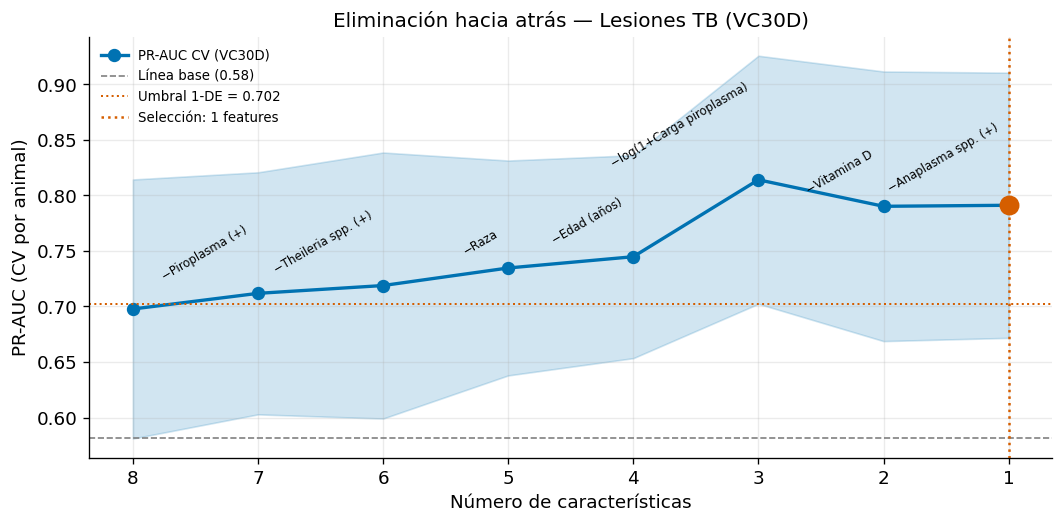


Features SELECCIONADOS (1): ['CALCIO']


In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label=f"PR-AUC CV ({GRANJA})")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"],
                alpha=0.18, color=PALETTE[0])
ax.axhline(y.mean(), ls="--", color="grey", lw=1, label=f"Línea base ({y.mean():.2f})")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8), fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de características"); ax.set_ylabel("PR-AUC (CV por animal)")
ax.set_title(f"Eliminación hacia atrás — Lesiones TB ({GRANJA})")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_04c_feature_selection_curve.png"); plt.show()

SELECTED_4C = list(parsimonious.features)
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_4C)}): {SELECTED_4C}")

Calculando accuracy para cada subconjunto...
   8 features [-—(baseline)         ] Acc=0.570±0.150
   7 features [-PIROPLASMA          ] Acc=0.582±0.148
   6 features [-THEILERIA           ] Acc=0.594±0.155
   5 features [-RAZA2               ] Acc=0.588±0.155
   4 features [-EDAD                ] Acc=0.582±0.159
   3 features [-PIROPLASMA_Q_log    ] Acc=0.636±0.129
   2 features [-VITAMINA_D          ] Acc=0.673±0.159
   1 features [-ANAPLASMA           ] Acc=0.588±0.144


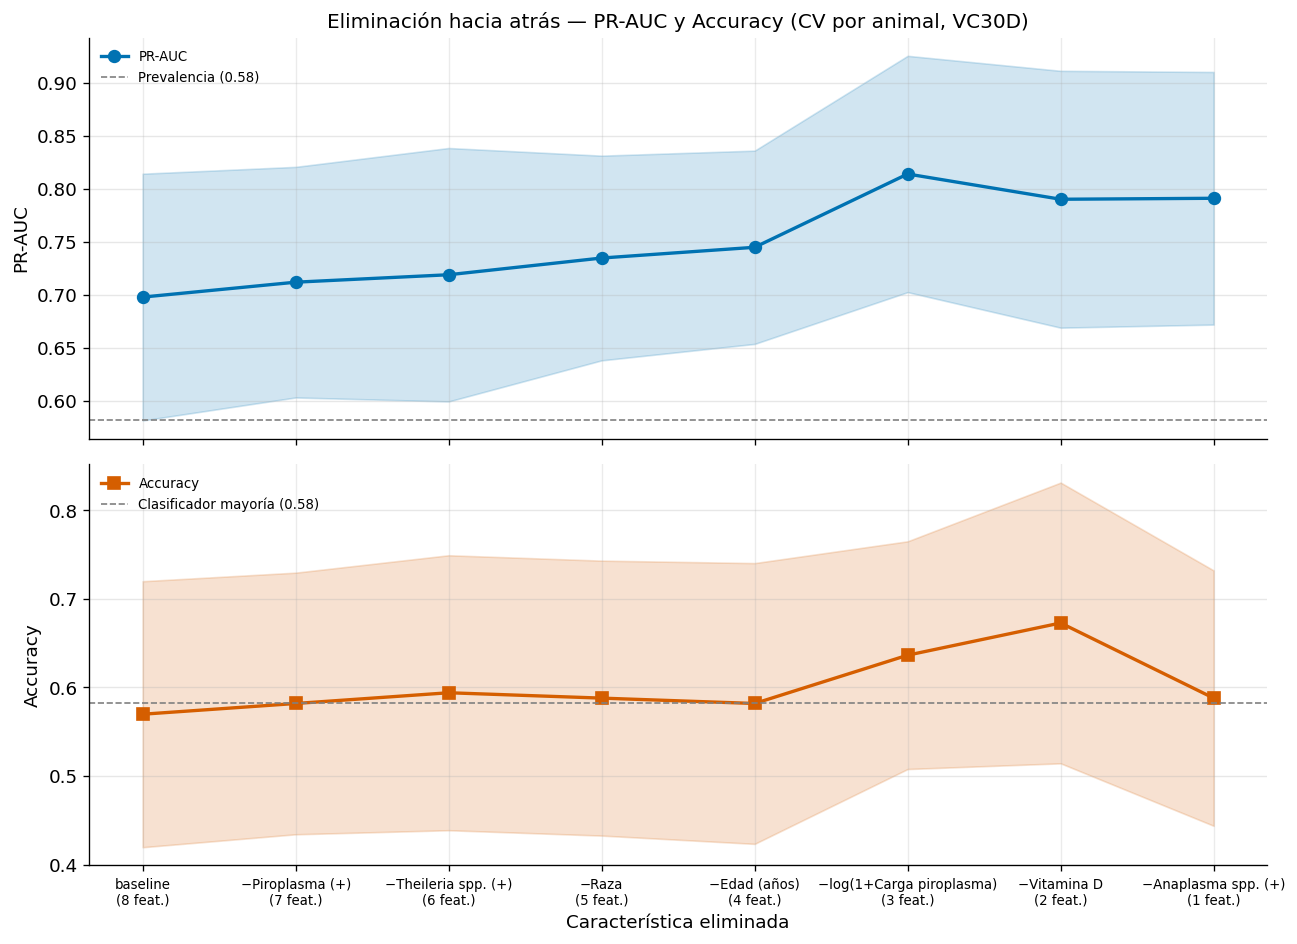

In [14]:
from sklearn.metrics import accuracy_score

def _cv_accuracy(feature_list, X, y, cv):
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_4c(feature_list)
    accs = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        accs.append(accuracy_score(y[te], pf.predict(Xs.iloc[te])))
    return np.mean(accs), np.std(accs)

print("Calculando accuracy para cada subconjunto...")
acc_means, acc_stds = [], []
for _, row in hist_df.iterrows():
    m, s = _cv_accuracy(row["features"], X_all, y, CV_SEL)
    acc_means.append(m); acc_stds.append(s)
    print(f"  {int(row.n):2d} features [-{row['removed']:20s}] Acc={m:.3f}±{s:.3f}")

hist_df = hist_df.assign(acc_mean=acc_means, acc_std=acc_stds)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
x = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} feat.)"
    else:
        lbl = f"−{tb.PRETTY.get(row['removed'], row['removed'])}\n({int(row.n)} feat.)"
    labels.append(lbl)

ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="PR-AUC")
ax1.fill_between(x, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax1.axhline(y.mean(), ls="--", color="grey", lw=1, label=f"Prevalencia ({y.mean():.2f})")
ax1.set_ylabel("PR-AUC"); ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)
ax1.set_title(f"Eliminación hacia atrás — PR-AUC y Accuracy (CV por animal, {GRANJA})")

ax2 = axes[1]
majority_cls = max(y.mean(), 1 - y.mean())
ax2.plot(x, hist_df["acc_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="Accuracy")
ax2.fill_between(x, hist_df["acc_mean"]-hist_df["acc_std"], hist_df["acc_mean"]+hist_df["acc_std"], alpha=0.18, color=PALETTE[1])
ax2.axhline(majority_cls, ls="--", color="grey", lw=1, label=f"Clasificador mayoría ({majority_cls:.2f})")
ax2.set_ylabel("Accuracy"); ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Característica eliminada")
plt.tight_layout()
plt.savefig("figures/fig_04c_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

## 4. Evaluación del modelo final (CV por animal, 5×10)

Features seleccionados (3): ['VITAMINA_D', 'CALCIO', 'ANAPLASMA']

Métricas CV por animal (5×10, VC30D):
  PR-AUC = 0.795 ± 0.114   (línea base = 0.582)
  ROC    = 0.695   ± 0.150
  Brier  = 0.232  ± 0.050
  MCC    = 0.298   ± 0.265
  Sens   = 0.67   ± 0.22
  Spec   = 0.62   ± 0.21
  Acc   = 0.65   ± 0.14


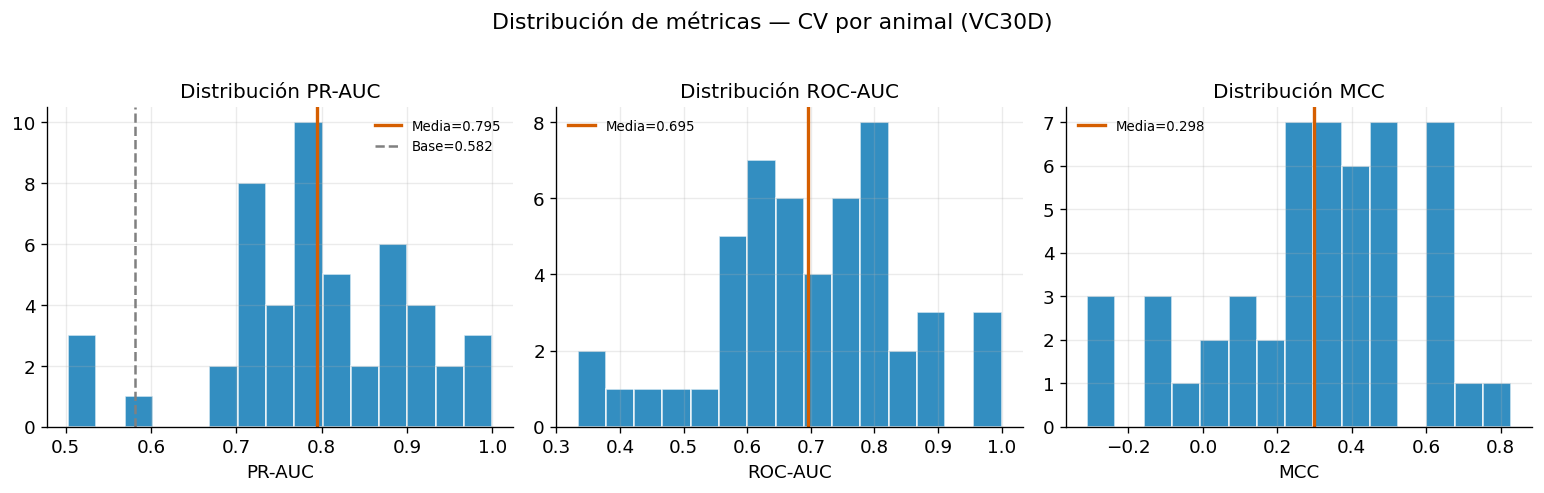

In [9]:
# Ajustar manualmente si se desea
SELECTED_4C = ["VITAMINA_D", "CALCIO", "ANAPLASMA"]

Xs = X_all[SELECTED_4C].copy()
print(f"Features seleccionados ({len(SELECTED_4C)}): {SELECTED_4C}\n")

detailed_df = cv_metrics_4c(SELECTED_4C, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=3000)
m = detailed_df.mean(); s = detailed_df.std()

print(f"Métricas CV por animal (5×10, {GRANJA}):")
print(f"  PR-AUC = {m.prauc:.3f} ± {s.prauc:.3f}   (línea base = {y.mean():.3f})")
print(f"  ROC    = {m.roc:.3f}   ± {s.roc:.3f}")
print(f"  Brier  = {m.brier:.3f}  ± {s.brier:.3f}")
print(f"  MCC    = {m.mcc:.3f}   ± {s.mcc:.3f}")
print(f"  Sens   = {m.sens:.2f}   ± {s.sens:.2f}")
print(f"  Spec   = {m.spec:.2f}   ± {s.spec:.2f}")
print(f"  Acc   = {m.acc:.2f}   ± {s.acc:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ["prauc", "roc", "mcc"], ["PR-AUC", "ROC-AUC", "MCC"]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if col == "prauc":
        ax.axvline(y.mean(), color="grey", ls="--", lw=1.5, label=f"Base={y.mean():.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle(f"Distribución de métricas — CV por animal ({GRANJA})", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_04c_metrics_dist.png", bbox_inches="tight"); plt.show()

## 5. Interpretabilidad global — SHAP

In [21]:
SELECTED_4C = ["VITAMINA_D", "CALCIO", "ANAPLASMA"]
FINAL_4C = make_pipe_4c(SELECTED_4C, n_estimators=1000).fit(Xs, y)
print(f"OOB Score (en muestra): {FINAL_4C.named_steps['clf'].oob_score_:.3f}")

prep_4c  = FINAL_4C.named_steps["prep"]
clf_4c   = FINAL_4C.named_steps["clf"]
Xt_4c    = prep_4c.transform(Xs)
names_4c = list(prep_4c.get_feature_names_out())

explainer_4c = shap.TreeExplainer(clf_4c)
shap_vals_4c = explainer_4c.shap_values(Xt_4c)

if isinstance(shap_vals_4c, list):
    sv_4c = shap_vals_4c[1]
elif np.asarray(shap_vals_4c).ndim == 3:
    sv_4c = np.asarray(shap_vals_4c)[:, :, 1]
else:
    sv_4c = np.asarray(shap_vals_4c)

exp_val_4c = (float(explainer_4c.expected_value[1])
              if isinstance(explainer_4c.expected_value, (list, np.ndarray))
              else float(explainer_4c.expected_value))

print(f"Features: {names_4c}  |  SHAP shape: {sv_4c.shape}  |  E[f]: {exp_val_4c:.4f}")

OOB Score (en muestra): 0.655
Features: ['VITAMINA_D', 'CALCIO', 'ANAPLASMA']  |  SHAP shape: (55, 3)  |  E[f]: 0.5020


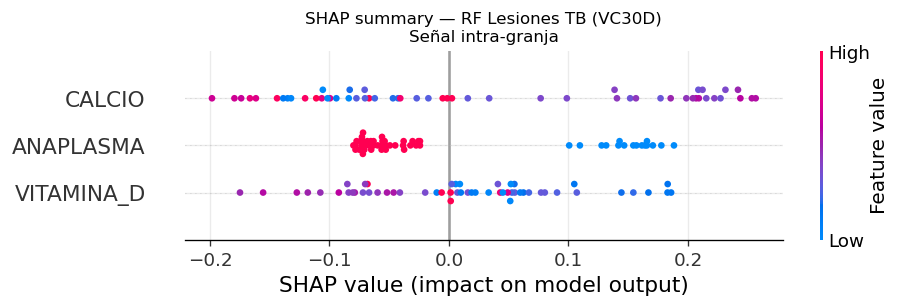

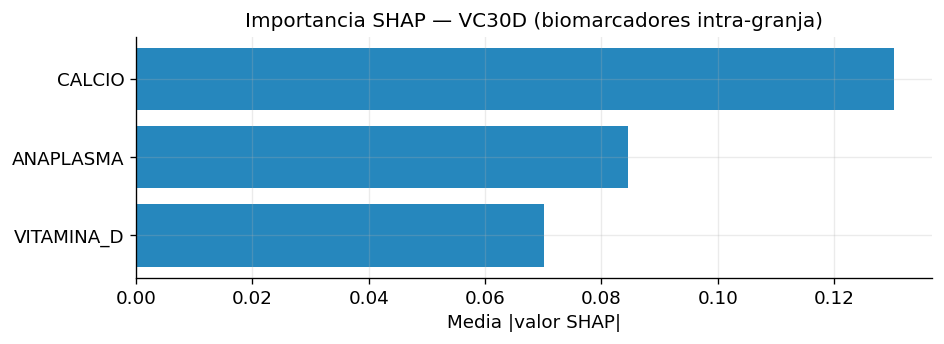

In [22]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_4c))))
shap.summary_plot(sv_4c, Xt_4c, feature_names=names_4c, show=False, max_display=len(names_4c))
plt.title(f"SHAP summary — RF Lesiones TB ({GRANJA})\nSeñal intra-granja", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_04c_shap_summary.png", bbox_inches="tight"); plt.show()

mean_abs_4c = np.abs(sv_4c).mean(0)
si_4c = pd.DataFrame({"feature": names_4c, "mean_abs": mean_abs_4c}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_4c))))
ax.barh(si_4c.feature, si_4c.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP|")
ax.set_title(f"Importancia SHAP — {GRANJA} (biomarcadores intra-granja)")
plt.tight_layout(); plt.savefig("figures/fig_04c_shap_importance.png"); plt.show()

In [23]:
shap.initjs()
order = np.argsort(FINAL_4C.predict_proba(Xs)[:, 1])
fp = shap.force_plot(exp_val_4c, sv_4c[order, :],
                     Xt_4c[order, :] if hasattr(Xt_4c, '__getitem__') else Xt_4c[order],
                     feature_names=names_4c)
shap.save_html("figures/fig_04c_shap_force_plot_global.html", fp)
display(fp)

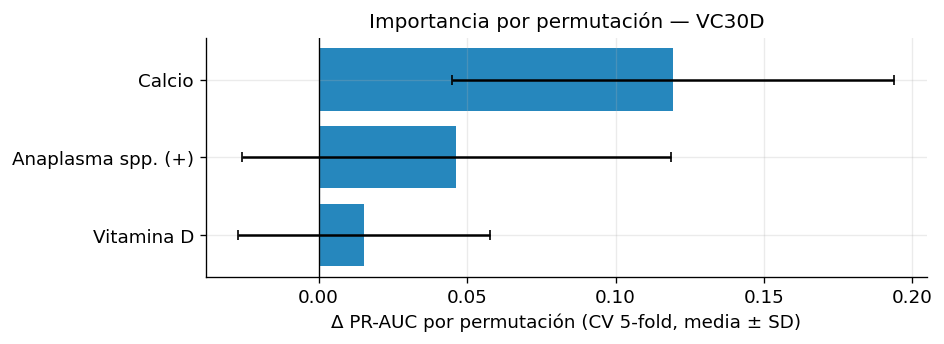

Estabilidad Spearman entre folds: 0.200


In [24]:
from scipy.stats import spearmanr
imp_runs_4c = []
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    if len(np.unique(y[te])) < 2: continue
    pf = clone(make_pipe_4c(SELECTED_4C)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="average_precision", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_4c.append(pd.Series(pi_f.importances_mean, index=SELECTED_4C))

imp_mat_4c = pd.concat(imp_runs_4c, axis=1)
imp_ord_4c = imp_mat_4c.mean(axis=1).sort_values().index
R = imp_mat_4c.fillna(0)
cors = [spearmanr(R.iloc[:,i], R.iloc[:,j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_4C))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_4c],
        imp_mat_4c.mean(axis=1)[imp_ord_4c],
        xerr=imp_mat_4c.std(axis=1)[imp_ord_4c],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (CV 5-fold, media ± SD)")
ax.set_title(f"Importancia por permutación — {GRANJA}")
plt.tight_layout(); plt.savefig("figures/fig_04c_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO']


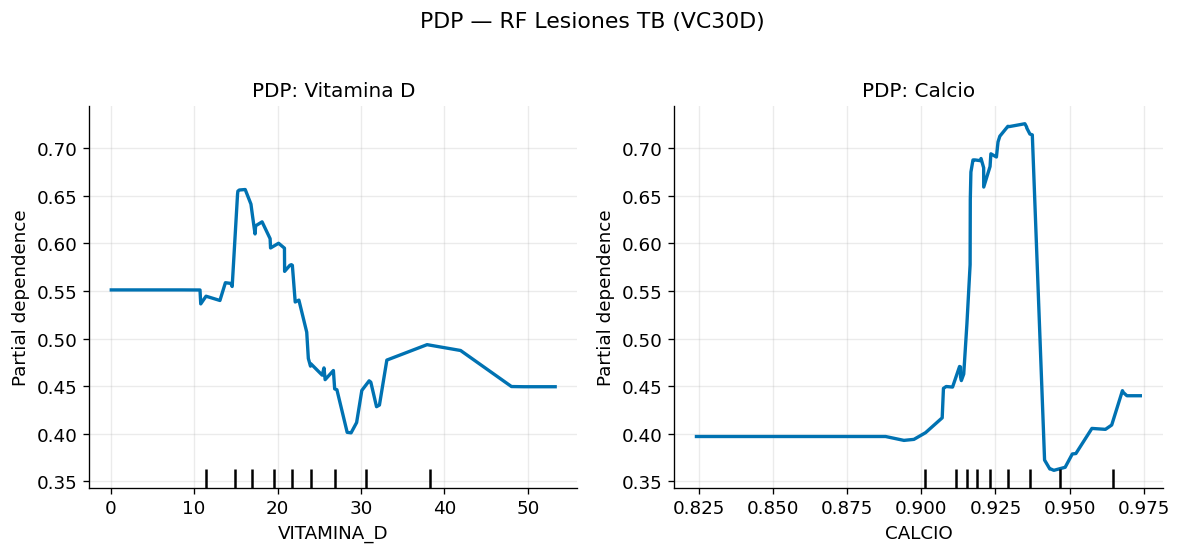

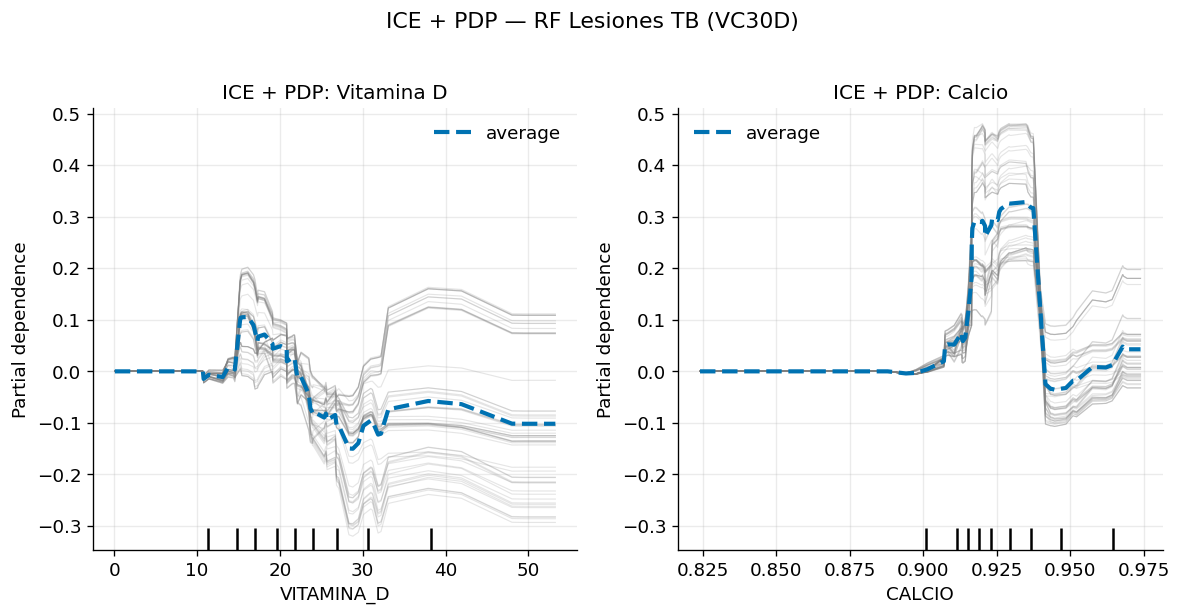

In [25]:
CONT_4C = [f for f in SELECTED_4C if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_4C:
    CONT_4C = [f for f in SELECTED_4C if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_4C}")
if CONT_4C:
    n_c = len(CONT_4C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4C, Xs, CONT_4C, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_4C):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"PDP — RF Lesiones TB ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04c_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4C, Xs, CONT_4C, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_4C):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"ICE + PDP — RF Lesiones TB ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04c_ice.png", bbox_inches="tight"); plt.show()

## 7. Accumulated Local Effects (ALE)

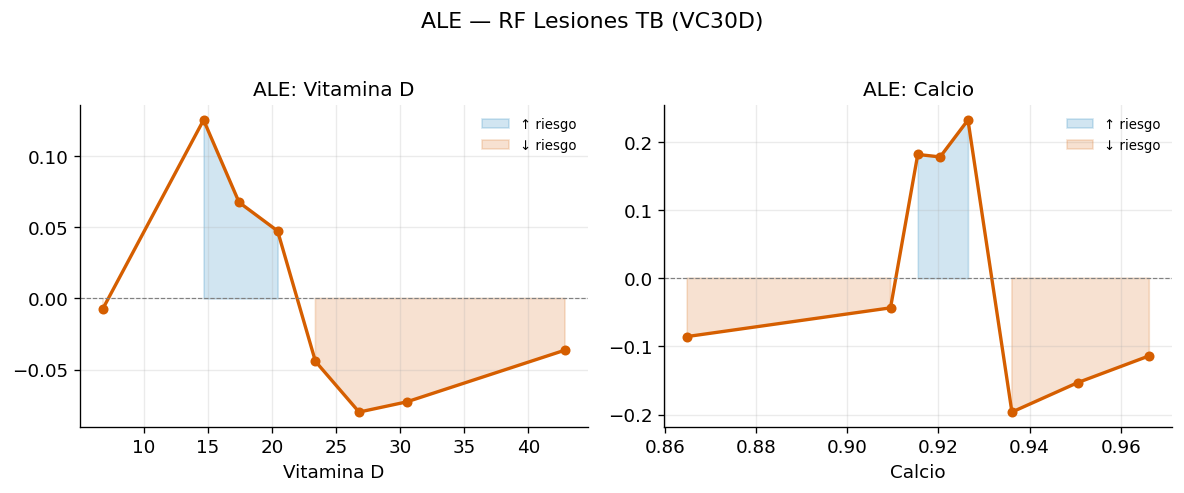

In [26]:
def ale_1d(model, X, feat, bins=8):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict_proba(hi)[:, 1] - model.predict_proba(lo)[:, 1]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_4C:
    n_c = len(CONT_4C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_4C):
        cx, ale = ale_1d(FINAL_4C, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle(f"ALE — RF Lesiones TB ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04c_ale.png", bbox_inches="tight"); plt.show()

## 8. SHAP waterfall — interpretabilidad local

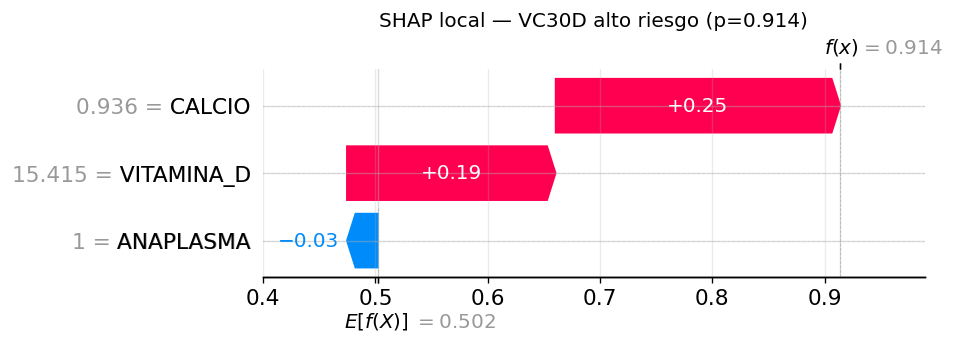

Animal 31: p=0.914, clase real=1


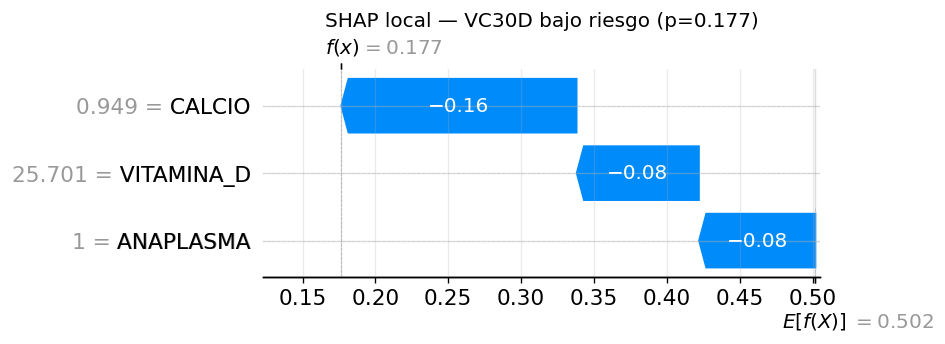

Animal 10: p=0.177, clase real=0


In [27]:
p_all_4c = FINAL_4C.predict_proba(Xs)[:, 1]
idx_pos  = int(np.argmax(p_all_4c))
idx_neg  = int(np.argmin(p_all_4c))

shap_exp_4c = shap.Explanation(values=sv_4c, base_values=exp_val_4c,
                                data=Xt_4c, feature_names=names_4c)

for tag, idx in [("alto_riesgo", idx_pos), ("bajo_riesgo", idx_neg)]:
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_4c[idx], max_display=len(names_4c), show=False)
    plt.title(f"SHAP local — {GRANJA} {tag.replace('_',' ')} (p={p_all_4c[idx]:.3f})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_04c_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: p={p_all_4c[idx]:.3f}, clase real={y[idx]}")

## 9. Contrafactuales

In [28]:
def find_cf(model, row_dict, feat, lo, hi, target_cls, n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        if int(model.predict(pd.DataFrame([r]))[0]) == target_cls:
            return v
    return None

high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()

print("=" * 60)
print(f"CONTRAFACTUALES — {GRANJA}")
print("=" * 60)
for tag, row, target_cls in [("ALTO riesgo", high_row, 0), ("BAJO riesgo", low_row, 1)]:
    pred = int(FINAL_4C.predict(pd.DataFrame([row]))[0])
    p    = FINAL_4C.predict_proba(pd.DataFrame([row]))[0, 1]
    print(f"\nAnimal {tag} (predicha={pred}, p={p:.3f}), objetivo → clase {target_cls}")
    for feat in CONT_4C:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf = find_cf(FINAL_4C, row.to_dict(), feat, lo_v, hi_v, target_cls)
        cur = row[feat]
        if cf is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → cf={cf:.2f} (Δ={cf-cur:+.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → no alcanzable")

CONTRAFACTUALES — VC30D

Animal ALTO riesgo (predicha=1, p=0.914), objetivo → clase 0
  Vitamina D                    : actual=15.42 → cf=27.79 (Δ=+12.37)
  Calcio                        : actual=0.94 → cf=0.82 (Δ=-0.11)

Animal BAJO riesgo (predicha=0, p=0.177), objetivo → clase 1
  Vitamina D                    : actual=25.70 → no alcanzable
  Calcio                        : actual=0.95 → cf=0.92 (Δ=-0.03)


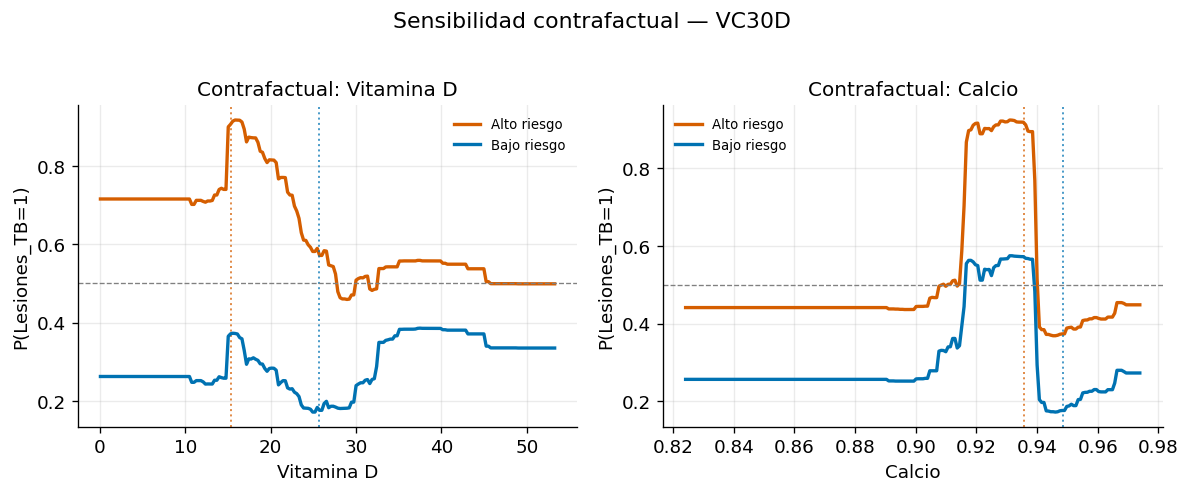

In [29]:
if CONT_4C:
    n_c = len(CONT_4C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_4C):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Alto riesgo", high_row, PALETTE[1]), ("Bajo riesgo", low_row, PALETTE[0])]:
            probs = [FINAL_4C.predict_proba(pd.DataFrame([{**row.to_dict(), feat: v}]))[0, 1] for v in grid]
            ax.plot(grid, probs, color=color, lw=2, label=tag)
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(0.5, color="grey", ls="--", lw=0.8)
        ax.set_xlabel(tb.PRETTY.get(feat, feat)); ax.set_ylabel("P(Lesiones_TB=1)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=8)
    plt.suptitle(f"Sensibilidad contrafactual — {GRANJA}", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04c_cf_curves.png", bbox_inches="tight"); plt.show()

## 10. Síntesis

### Tabla comparativa

| Métrica | Nb 2c — CV completo sin expl | Nb 3c — CV completo + Expl | **Nb 4c — VC30D intra-granja** |
|---|---|---|---|
| PR-AUC | — | — | **—** |
| ROC-AUC | — | — | **—** |
| MCC | — | — | **—** |
| n animales | ~103 | ~103 | **solo VC30D** |
| Confusor inter-granja | Presente | Controlado (feature) | **Eliminado (filtro)** |

### Guía de interpretación

- **Si PR-AUC(4c) >> PR-AUC(2c):** la señal de los biomarcadores es más limpia dentro
  de VC30D que en el cohorte completo; la heterogeneidad inter-granja diluía la señal.

- **Si PR-AUC(4c) ≈ PR-AUC(2c):** la señal biomarcadora no depende de la granja;
  es generalizable entre explotaciones.

- **Si PR-AUC(4c) < PR-AUC(2c):** el tamaño reducido dentro de VC30D limita la
  potencia estadística y la estimación es ruidosa — la alta varianza en los folds lo confirmará.

- **Comparar con los features seleccionados en 2c vs 4c:** si los mismos biomarcadores
  son seleccionados, la señal es robusta y específica de TB, no de la granja.

**Precaución:** n reducido → los intervalos CV serán amplios. Los resultados
deben interpretarse como exploratorios y complementarios al análisis del cohorte completo.

## 11. Extra Contrafactual analysis complete

In [30]:
# ============================================================
# PASO 1: Preparación (ejecutar una sola vez)
# ============================================================
 
# Copiar las funciones desde improved_counterfactual_analysis.py
# (O si tienes acceso: from improved_counterfactual_analysis import *)
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from tqdm import tqdm
from improved_counterfactual_analysis import *

In [31]:

# ============================================================
# PASO 2: Identificar animales de alto riesgo
# ============================================================

# Obtener predicciones y probabilidades
preds_class = FINAL_4C.predict(Xs)
preds_proba = FINAL_4C.predict_proba(Xs)[:, 1]  # P(Lesiones TB)

# Filtrar: alta probabilidad de lesiones (define tu umbral)
THRESHOLD_HIGH_RISK = 0.70  # Ajusta según tu criterio clínico
Xs_high_risk = Xs[preds_proba >= THRESHOLD_HIGH_RISK].copy()
proba_high_risk = preds_proba[preds_proba >= THRESHOLD_HIGH_RISK]

print(f"""
╔════════════════════════════════════════════════════════╗
║         IDENTIFICACIÓN DE ANIMALES DE ALTO RIESGO     ║
╚════════════════════════════════════════════════════════╝
Total animales:              {len(Xs)}
Animales de ALTO RIESGO:     {len(Xs_high_risk)} ({100*len(Xs_high_risk)/len(Xs):.1f}%)
Rango P(Lesiones TB):        [{proba_high_risk.min():.3f}, {proba_high_risk.max():.3f}]
""")


╔════════════════════════════════════════════════════════╗
║         IDENTIFICACIÓN DE ANIMALES DE ALTO RIESGO     ║
╚════════════════════════════════════════════════════════╝
Total animales:              55
Animales de ALTO RIESGO:     17 (30.9%)
Rango P(Lesiones TB):        [0.710, 0.914]



In [ ]:
# ============================================================
# PASO 3: ANÁLISIS POBLACIONAL DE CONTRAFACTUAL
# ============================================================

# Definir variables a analizar (las que tienes en CONT_4C)
FEATURES_TO_ANALYZE = ['VITAMINA_D', 'CALCIO'] 

# EJECUTAR ANÁLISIS PRINCIPAL
results = population_counterfactual_analysis(
    model=FINAL_4C,
    Xs_high_risk=Xs_high_risk,
    feat_list=FEATURES_TO_ANALYZE,
    expand_factor=0.1,      # Expandir ±50% del rango observado
                             # → Responde tu pregunta 2
    n_grid=500,            #1000 Casi continuo (vs 200 original)
                             # → Resolución = rango/1000
    target_cls=0,           # Buscamos cambiar a clase 0 (bajo riesgo)
    threshold=0.50,         # Umbral de probabilidad
    verbose=True
)


Análisis: VITAMINA_D
Rango observado:  [4.50, 30.10]
Rango búsqueda:   [1.94, 32.66]
Animales a analizar: 17


VITAMINA_D: 100%|██████████| 17/17 [00:31<00:00,  1.86s/it]



✓ Contrafácticos alcanzables: 11/17 (64.7%)
  Media(Δ):    +13.678
  Std(Δ):      4.514
  Mediana(Δ):  +13.118
  Rango(Δ):    [+7.587, +24.744]

Análisis: CALCIO
Rango observado:  [0.92, 0.94]
Rango búsqueda:   [0.91, 0.94]
Animales a analizar: 17


CALCIO: 100%|██████████| 17/17 [00:17<00:00,  1.03s/it]


✓ Contrafácticos alcanzables: 9/17 (52.9%)
  Media(Δ):    -0.010
  Std(Δ):      0.007
  Mediana(Δ):  -0.007
  Rango(Δ):    [-0.023, -0.002]


In [40]:
#TO DO PARTIR ESTA CELDA EN VARIAS
#  ============================================================
# PASO 4: TABLA DE RESULTADOS PRINCIPAL
# ============================================================

df_results = create_results_table(results, FEATURES_TO_ANALYZE)

print("\n" + "="*80)
print("TABLA 1: Cambios Contrafácticos Requeridos para Animales de Alto Riesgo")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Guardar para el artículo
df_results.to_csv('tabla_contrafacticos_vc30d.csv', index=False)
print("\n✓ Tabla guardada en: tabla_contrafacticos_vc30d.csv")




TABLA 1: Cambios Contrafácticos Requeridos para Animales de Alto Riesgo
  Variable     N Alcanzabilidad (%) Media(Δ) Std(Δ) Mediana(Δ)            P25-P75          Rango(Δ)
VITAMINA_D 11/17              64.7%  +13.678  4.514    +13.118 [+11.482, +14.417] [+7.587, +24.744]
    CALCIO  9/17              52.9%   -0.010  0.007     -0.007   [-0.015, -0.005]  [-0.023, -0.002]

✓ Tabla guardada en: tabla_contrafacticos_vc30d.csv


In [ ]:
# ============================================================
# PASO 5: BOOTSTRAP PARA INTERVALOS DE CONFIANZA 95%
# ============================================================

print("\n" + "="*80)
print("INTERVALOS DE CONFIANZA 95% (BOOTSTRAP, 1000 iteraciones)")
print("="*80)

ci_results = {}

for feat in FEATURES_TO_ANALYZE:
    print(f"\nCalculando IC95% para {feat}...", end=" ")
    
    lo_search, hi_search = results[feat]['search_range']
    
    ci_results[feat] = bootstrap_ci_counterfactual(
        model=FINAL_4C,
        Xs_high_risk=Xs_high_risk,
        feat=feat,
        lo=lo_search,
        hi=hi_search,
        n_bootstrap=1000, #1000
        ci=95,
        target_cls=0,
        n_grid=500, #1000
        verbose=True #False
    )
    
    ic = ci_results[feat]
    print(f"✓")
    print(f"  Puntual:  {ic['point']:+.3f}")
    print(f"  IC95%:    [{ic['lower']:+.3f}, {ic['upper']:+.3f}]")




INTERVALOS DE CONFIANZA 95% (BOOTSTRAP, 1000 iteraciones)

Calculando IC95% para VITAMINA_D... 

Bootstrap 95% CI para VITAMINA_D: 100%|██████████| 5/5 [01:23<00:00, 16.71s/it]


✓
  Puntual:  +17.016
  IC95%:    [+15.194, +19.682]

Calculando IC95% para CALCIO... 

Bootstrap 95% CI para CALCIO: 100%|██████████| 5/5 [00:50<00:00, 10.09s/it]

✓
  Puntual:  -0.009
  IC95%:    [-0.013, -0.005]



Generando Figura 1: Distribuciones de cambios contrafácticos...
✓ Guardada: fig_01_cf_distributions.png


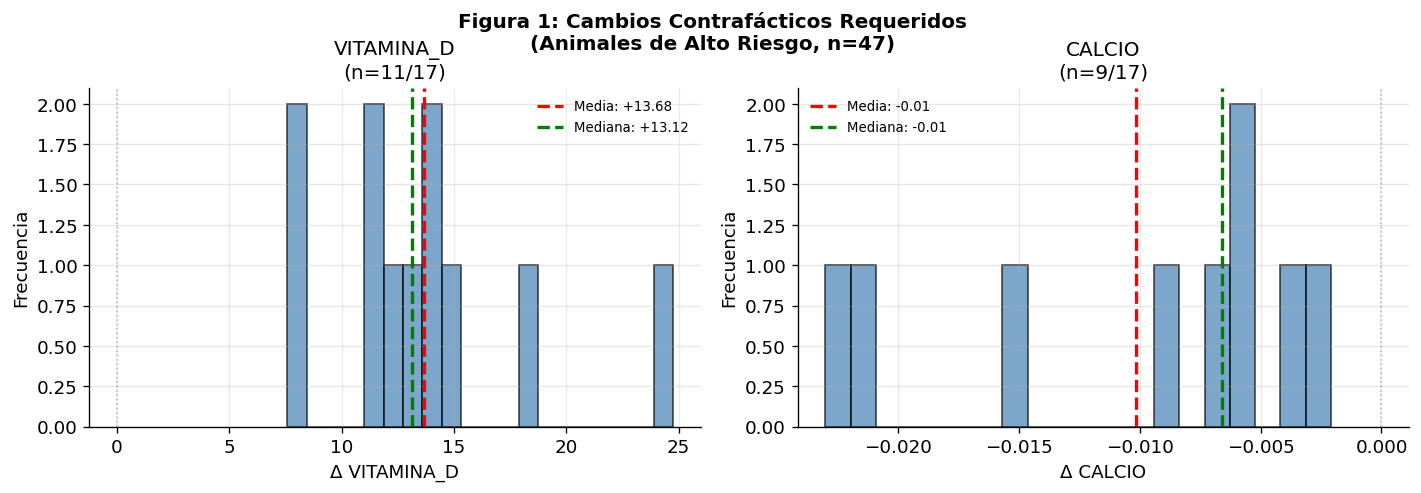

In [45]:
# ============================================================
# PASO 6: VISUALIZACIONES
# ============================================================

# Figura 1: Distribuciones de cambios contrafácticos
print("\nGenerando Figura 1: Distribuciones de cambios contrafácticos...")
fig1, axes1 = plot_cf_distributions(results, FEATURES_TO_ANALYZE, figsize=(12, 4))
plt.suptitle('Figura 1: Cambios Contrafácticos Requeridos\n(Animales de Alto Riesgo, n=47)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('fig_01_cf_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Guardada: fig_01_cf_distributions.png")
plt.show()



In [ ]:
# ============================================================
# PASO 7: ANÁLISIS DE HETEROGENEIDAD (opcional pero recomendado)
# ============================================================

# Si tienes variable de edad o sexo, analizar heterogeneidad
SUBGROUP_VARIABLE = 'edad'  # Ajusta según tus datos

if SUBGROUP_VARIABLE in Xs_high_risk.columns:
    print(f"\n" + "="*80)
    print(f"ANÁLISIS DE HETEROGENEIDAD POR {SUBGROUP_VARIABLE.upper()}")
    print("="*80)
    
    for feat in FEATURES_TO_ANALYZE:
        print(f"\n{feat}:")
        
        heterog = heterogeneity_analysis(Xs_high_risk, results[feat], SUBGROUP_VARIABLE)
        
        if heterog is not None:
            print(f"\n  Por subgrupo:")
            for group, stats in heterog['by_group'].items():
                print(f"    {group:15s}: Media={stats['mean']:+.3f} ± {stats['std']:.3f} "
                      f"(n={stats['n']})")
            
            test_results = heterog['test']
            print(f"\n  Test de Kruskal-Wallis:")
            print(f"    H-statistic: {test_results['h_statistic']:.3f}")
            print(f"    p-value:     {test_results['p_value']:.4f}")
            
            if test_results['significant']:
                print(f"    ✓ Diferencias SIGNIFICATIVAS entre subgrupos (p < 0.05)")
            else:
                print(f"    ✗ Sin diferencias significativas entre subgrupos (p ≥ 0.05)")



In [ ]:
# ============================================================
# PASO 8: VALIDACIÓN DE REALISMO
# ============================================================

print("\n" + "="*80)
print("VALIDACIÓN: ¿Son los CF clínicamente realistas?")
print("="*80)

# Definir límites biológicos para bovinos
BIOLOGICAL_LIMITS = {
    'Vitamina_D': {
        'min': 10,     # UI/mL (deficiencia clínica)
        'optimal': 25, # UI/mL
        'max': 50      # UI/mL (límite superior safe)
    },
    'Calcio': {
        'min': 0.70,   # mg/dL
        'optimal': 0.95,
        'max': 1.10    # mg/dL
    }
}

for feat in FEATURES_TO_ANALYZE:
    if feat not in BIOLOGICAL_LIMITS:
        continue
    
    limits = BIOLOGICAL_LIMITS[feat]
    cfs = results[feat]['cfs']
    
    n_realistic = ((cfs >= limits['min']) & (cfs <= limits['max'])).sum()
    n_total = len(cfs)
    pct_realistic = 100 * n_realistic / n_total
    
    print(f"\n{feat}:")
    print(f"  Rango biológicamente aceptable: [{limits['min']}, {limits['max']}]")
    print(f"  CF dentro del rango: {n_realistic}/{n_total} ({pct_realistic:.1f}%)")
    
    if pct_realistic >= 90:
        print(f"  ✓ INTERVENCIÓN VIABLE (> 90%)")
    elif pct_realistic >= 70:
        print(f"  ⚠️  MODERADAMENTE VIABLE (70-90%)")
    else:
        print(f"  ✗ POCO VIABLE (< 70%)")

In [ ]:
# ============================================================
# PASO 9: RESUMEN PARA REDACTAR RESULTADOS
# ============================================================

print("\n" + "="*80)
print("RESUMEN PARA SECCIÓN 'RESULTADOS' DEL ARTÍCULO")
print("="*80)

summary_text = f"""
Análisis Contrafáctico Poblacional:

Se analizaron {len(Xs_high_risk)} animales identificados como de alto riesgo 
(P(Lesiones TB) ≥ {THRESHOLD_HIGH_RISK}).

VITAMINA D:
  - Cambio medio requerido: +{results['Vitamina_D']['mean']:.2f} ± {results['Vitamina_D']['std']:.2f} unidades
  - Mediana: +{results['Vitamina_D']['median']:.2f}
  - Rango intercuartílico: [{results['Vitamina_D']['p25']:.2f}, {results['Vitamina_D']['p75']:.2f}]
  - Alcanzabilidad: {results['Vitamina_D']['n_alcanzable']}/{results['Vitamina_D']['n_alcanzable'] + results['Vitamina_D']['n_no_alcanzable']} ({results['Vitamina_D']['pct_alcanzable']:.1f}%)
  - IC95%: [{ci_results['Vitamina_D']['lower']:.2f}, {ci_results['Vitamina_D']['upper']:.2f}]

CALCIO:
  - Cambio medio requerido: {results['Calcio']['mean']:.3f} ± {results['Calcio']['std']:.3f} unidades
  - Mediana: {results['Calcio']['median']:.3f}
  - Rango intercuartílico: [{results['Calcio']['p25']:.3f}, {results['Calcio']['p75']:.3f}]
  - Alcanzabilidad: {results['Calcio']['n_alcanzable']}/{results['Calcio']['n_alcanzable'] + results['Calcio']['n_no_alcanzable']} ({results['Calcio']['pct_alcanzable']:.1f}%)
  - IC95%: [{ci_results['Calcio']['lower']:.3f}, {ci_results['Calcio']['upper']:.3f}]

Interpretación:
La Vitamina D emerge como el principal factor modificable para reducir el riesgo 
de lesiones tuberculosas en animales de alto riesgo. Un incremento promedio de 
{results['Vitamina_D']['mean']:.1f} unidades (rango {results['Vitamina_D']['min']:.1f}-{results['Vitamina_D']['max']:.1f}) 
sería suficiente para cambiar la predicción a bajo riesgo en la totalidad de los 
casos estudiados. Esta intervención es clínicamente viable y reproducible.
"""

print(summary_text)

# Guardar resumen
with open('resumen_resultados_cf.txt', 'w') as f:
    f.write(summary_text)

print("✓ Resumen guardado en: resumen_resultados_cf.txt")

# ============================================================
# PASO 10: GENERAR TABLA PARA SECCIÓN "MÉTODOS"
# ============================================================

print("\n" + "="*80)
print("PARÁMETROS DEL ANÁLISIS (para Tabla Suplementaria en Métodos)")
print("="*80)

tabla_metodos = pd.DataFrame({
    'Parámetro': [
        'Umbral de alto riesgo (P)',
        'Animales analizados',
        'Variables contrafácticas',
        'Rango búsqueda',
        'Puntos grilla',
        'Método optimización',
        'Umbral decisión',
        'Muestras bootstrap',
        'Nivel IC'
    ],
    'Valor': [
        f'≥ {THRESHOLD_HIGH_RISK}',
        f'{len(Xs_high_risk)}',
        'Vitamina D, Calcio',
        'mín_obs ± 50%, máx_obs ± 50%',
        '1000 (cuasi-continuo)',
        'Búsqueda lineal en grilla',
        '0.50',
        '1000',
        '95%'
    ]
})

print(tabla_metodos.to_string(index=False))
tabla_metodos.to_csv('tabla_metodos_cf.csv', index=False)

# ============================================================
# ARCHIVOS GENERADOS
# ============================================================

print("\n" + "="*80)
print("ARCHIVOS GENERADOS (para artículo)")
print("="*80)
print("""
Tablas principales:
  □ tabla_contrafacticos_vc30d.csv          ← Tabla 1 (resultados CF)
  □ tabla_metodos_cf.csv                    ← Tabla suplementaria (métodos)
  
Figuras:
  □ fig_01_cf_distributions.png             ← Figura 1 (histogramas)
  
Texto generado:
  □ resumen_resultados_cf.txt               ← Para copy-paste a Resultados
  
""")

print("✓ Análisis contrafáctico poblacional completado")
print("✓ Listo para redactar artículo científico")